In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-31T01:53:34.916358+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.10.7
pyarrow   : 16.1.0
numpy     : 2.1.2
requests  : 2.34.2
pandas    : 2.2.3
scipy     : 1.14.1
marimo    : 0.23.2
seaborn   : 0.13.2
teeplot   : 1.4.2

```

## Data

Load the per-replicate Hamming-weight **end-state** table for the
4-site mutation-rate sweep, combining three slurm jobs (all driven
by notebook `bindle/2026-05-20-founder.py`, fixing `N_SITES=4` and
`POP_SIZE=1,000,000` on CPU, engine=numpy) that together cover the
swept range at two different equilibration depths:

- **deep** sweep
  (`slurm/2026-08-26/2026-08-26-4site-mutation-sweep.sh`, OSF
  https://osf.io/96r2v): `MUTATION_RATE` from `1e-5` down to
  `3e-11` (~2 points per decade, 12 conditions planned), 25
  replicates per condition (300 planned), **`N_STEPS=150,000`**.
- **wide / high-rate** sweep
  (`slurm/2026-08-29/2026-08-29-4site-mutation-sweep.sh`, OSF
  https://osf.io/m6hzn): `MUTATION_RATE` from `1e-1` down to
  `3e-6` (~2 points per decade, 10 conditions), 200 replicates per
  condition (2000 planned), **`N_STEPS=5,000`**.
- **wide / low-rate** sweep
  (`slurm/2026-08-30/2026-08-30-4site-mutation-sweep.sh`, OSF
  https://osf.io/buz8e): `MUTATION_RATE` from `1e-6` down to
  `3e-11` (10 conditions), 200 replicates per condition (2000
  planned), **`N_STEPS=5,000`**, seeded from 201 to avoid
  replicate-uid collisions with the other two sweeps.

Both wide sweeps use a much shorter run than the deep sweep because
dynamics saturate quickly relative to `N_STEPS=150,000`; they trade
that depth for ~8x the replicate count, deliberately **duplicating**
the deep sweep's rate range rather than avoiding it, to get a
larger-N shallow estimate at the same conditions. The wide/low-rate
sweep's 10 rungs (`1e-6` .. `3e-11`) fully overlap the deep sweep's
bottom 10 rungs, so at those `mutation_rate` values this notebook
holds replicates from **two different equilibration depths**
(150,000 vs. 5,000 steps) that are not directly comparable --- the
`mutation_rate x n_steps x replicate counts` diagnostic printed
below shows exactly where that overlap falls, and every downstream
cell groups by `(mutation_rate, n_steps)` rather than
`mutation_rate` alone, keeping the two depths as separate series
(see the `n_steps`-styled lines in the plot below) instead of
blending them into one estimate.

The deep sweep was still in flight when this notebook was written:
not every planned condition has completed replicates yet, and
completed conditions can have far fewer than 25 replicates apiece.
Both wide sweeps are essentially complete (200 replicates at every
condition, except the high-rate sweep's `3e-4`, which has 180).
Treat the deep sweep's confidence intervals as provisional
accordingly (they should tighten, and any missing conditions fill
in, as the sweep continues and its OSF file is refreshed).

All three OSF files back this notebook as **full per-step
trajectory tables** (one row per `(replicate_uid, Step, hw)`)
rather than pre-filtered end-state exports, so loading any of them
wholesale with `pandas` risks exhausting memory. Instead, each
file's final-step filter (`Step == max(Step)`, computed per file
since `N_STEPS` differs between the deep and wide sweeps) is
pushed down through `pyarrow.dataset` before materializing to
`pandas` and concatenating, since every completed replicate is
recorded densely for every step (no checkpointing).

All three OSF files are downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copies.

In [ ]:
# CLI args. Defaults pull the three 4-site mutation-sweep hw
# parquets that back this notebook: deep (OSF https://osf.io/96r2v),
# wide/high-rate (OSF https://osf.io/m6hzn), and wide/low-rate (OSF
# https://osf.io/buz8e) --- see the Data section above.
_args = mo.cli_args()
_default_slugs = {
    "deep": "96r2v",
    "wide_high": "m6hzn",
    "wide_low": "buz8e",
}
OSF_SOURCES = {}
for _name, _default_slug in _default_slugs.items():
    _slug = str(_args.get(f"osf-slug-{_name}") or _default_slug)
    _url = str(
        _args.get(f"osf-url-{_name}")
        or f"https://osf.io/{_slug}/download",
    )
    OSF_SOURCES[_name] = (_slug, _url)
    print(f"args: OSF_SLUG_{_name}={_slug} OSF_URL_{_name}={_url}")

args: OSF_SLUG_deep=96r2v OSF_URL_deep=https://osf.io/96r2v/download
args: OSF_SLUG_wide_high=m6hzn OSF_URL_wide_high=https://osf.io/m6hzn/download
args: OSF_SLUG_wide_low=buz8e OSF_URL_wide_low=https://osf.io/buz8e/download


In [ ]:
def _download(slug, url):
    cache_path = pathlib.Path("/tmp") / slug
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=300)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

cache_paths = {
    _name: _download(_slug, _url)
    for _name, (_slug, _url) in OSF_SOURCES.items()
}

downloading https://osf.io/96r2v/download -> /tmp/96r2v
size: 249699504 bytes
downloading https://osf.io/m6hzn/download -> /tmp/m6hzn
size: 257102274 bytes
downloading https://osf.io/buz8e/download -> /tmp/buz8e
size: 160239028 bytes


In [ ]:
def _load_final_step(cache_path):
    # Each parquet is the full per-step trajectory table for its
    # sweep, so avoid pd.read_parquet(cache_path) --- loading every
    # step of every replicate into pandas is enough on its own to
    # exhaust memory on a typical runner. Every completed replicate
    # is recorded densely for every step (no checkpointing), so
    # pushing a Step == max(Step) filter down through pyarrow
    # before converting to pandas recovers exactly the end-state
    # rows at a fraction of the memory cost. max(Step) is computed
    # per file since N_STEPS differs between the deep and wide
    # sweeps.
    _dataset = ds.dataset(cache_path, format="parquet")
    _max_step = pc.max(
        _dataset.to_table(columns=["Step"])["Step"],
    ).as_py()
    return _dataset.to_table(
        filter=(pc.field("Step") == _max_step),
        columns=[
            "hw",
            "n_cases",
            "replicate_uid",
            "mutation_rate",
            "n_sites",
            "n_steps",
        ],
    ).to_pandas()

hw_df = pd.concat(
    [_load_final_step(_p) for _p in cache_paths.values()],
    ignore_index=True,
)
print(f"loaded hw end-state dataframe: {hw_df.shape}")
print(
    "mutation_rate x n_steps x replicate counts:\n"
    + str(
        hw_df.groupby(["mutation_rate", "n_steps"])[
            "replicate_uid"
        ].nunique(),
    ),
)

loaded hw end-state dataframe: (20400, 6)
mutation_rate x n_steps x replicate counts:
mutation_rate  n_steps
3.000000e-11   5000       200
               150000      11
1.000000e-10   5000       200
               150000      10
3.000000e-10   5000       200
                         ... 
1.000000e-03   5000       200
3.000000e-03   5000       200
1.000000e-02   5000       200
3.000000e-02   5000       200
1.000000e-01   5000       200
Name: replicate_uid, Length: 29, dtype: int64


## Fixation Outcome per Replicate

For each replicate, identify the **dominant Hamming-weight class**
at its final simulation step by case count (`n_cases`) --- the
Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used
in the founder-convergence analyses.

With `N_SITES=4` there are five Hamming-weight classes drawn from
the sixteen possible genomes:

- **founder strain (0000/1111)**: Hamming weights `0` and `4`,
  i.e. the all-zero founder/wildtype genome and its bitwise
  complement (`hw in {0, 4}`, 2 of the 16 genomes).
- **HW 1/3 complements**: Hamming weights `1` and `3`, the one-
  and three-mutation classes that are bitwise complements of one
  another (`hw in {1, 3}`, 8 of the 16 genomes).
- **HW 2 self-complementary**: Hamming weight `2`, the
  two-mutation class that is its own bitwise complement (`hw == 2`,
  the remaining 6 of the 16 genomes).

We classify each replicate's end-state into one of these three
categories, then ask how the **fixation probability of each
class** depends on the swept `mutation_rate`. Splitting HW 1/3 from
HW 2 (rather than lumping all of `hw in {1, 2, 3}` together, as the
2-/3-site companion notebooks do) matters here because the two
classes carry different genome counts (8 vs. 6 of 16) and thus
different chance baselines.

In [ ]:
_n_sites = int(hw_df["n_sites"].iloc[0])

# hw_df already holds one row per (replicate_uid, hw) at each
# replicate's final step (filtered upstream in load_data), so the
# dominant Hamming-weight class per replicate is just the hw with
# the largest n_cases.
_dom_idx = hw_df.groupby("replicate_uid")["n_cases"].idxmax()
outcome_df = hw_df.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "n_steps", "hw"],
].copy()

# Founder strain (0000/1111) == extreme Hamming weights {0, N_SITES};
# HW 2 == the self-complementary middle weight (N_SITES / 2); the
# remaining weights are the HW 1/3 complement pair.
outcome_df["group"] = outcome_df["hw"].map(
    lambda _hw: "founder (0000/1111)"
    if _hw in (0, _n_sites)
    else "HW 2 (self-complementary)"
    if _hw == _n_sites // 2
    else "HW 1/3 (complements)",
)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (4080, 5)
dominant hw class counts:
hw
0     976
1     487
2    1973
3     347
4     297
Name: count, dtype: int64
group counts:
group
HW 2 (self-complementary)    1973
founder (0000/1111)          1273
HW 1/3 (complements)          834
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

Each replicate's dominant-class label is one of three mutually
exclusive, collectively exhaustive outcomes, so for each
`(mutation_rate, n_steps)` condition the "class X fixes vs. it
doesn't" indicator is a Bernoulli trial per replicate and the
per-condition fraction is a **binomial proportion**. Conditions are
grouped by `n_steps` as well as `mutation_rate` --- not
`mutation_rate` alone --- since the deep and wide sweeps overlap at
several rates but ran to different depths (150,000 vs. 5,000
steps) and shouldn't be pooled into one proportion. We summarize
each of the three group proportions independently with the **exact
Clopper-Pearson interval** via `scipy.stats.binomtest(k,
n).proportion_ci(method="exact")` --- an exact estimator CI
inverted from the binomial CDF, **not** a bootstrap.
Per-condition replicate counts in this sweep snapshot are uneven
and can be as low as single digits for the deep sweep (vs. its
planned 25), so expect some of those intervals --- especially at
the sparser conditions --- to be wide.

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_rows = []
for (_mr, _steps), _sub in outcome_df.groupby(
    ["mutation_rate", "n_steps"],
):
    _n = len(_sub)
    _counts = _sub["group"].value_counts()
    for _group in _groups:
        _k = int(_counts.get(_group, 0))
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "n_steps": int(_steps),
                "group": _group,
                "n_fixed": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(
        ["group", "n_steps", "mutation_rate"],
    )
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate  n_steps                     group  n_fixed  n_total        p   ci_low  ci_high
  3.000000e-11     5000      HW 1/3 (complements)        5      200 0.025000 0.008166 0.057374
  1.000000e-10     5000      HW 1/3 (complements)       15      200 0.075000 0.042583 0.120684
  3.000000e-10     5000      HW 1/3 (complements)       32      200 0.160000 0.112087 0.218299
  1.000000e-09     5000      HW 1/3 (complements)       71      200 0.355000 0.288784 0.425586
  3.000000e-09     5000      HW 1/3 (complements)       88      200 0.440000 0.370056 0.511750
  1.000000e-08     5000      HW 1/3 (complements)      100      200 0.500000 0.428658 0.571342
  3.000000e-08     5000      HW 1/3 (complements)       81      200 0.405000 0.336335 0.476525
  1.000000e-07     5000      HW 1/3 (complements)       55      200 0.275000 0.214377 0.342425
  3.000000e-07     5000      HW 1/3 (complements)       66      200 0.330000 0.265298 0.399829
  1.000000e-06     5000      HW 1/3 (complements) 

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition fixation probability
against `mutation_rate` on a **log x-axis**, one line per outcome
group **and** per `n_steps` depth (solid vs. dashed line style,
since at several `mutation_rate` rungs the deep and wide sweeps
both contribute a series --- see the Data section above --- and
those two depths are kept visually distinct rather than merged).
The shaded **band shows the exact (Clopper-Pearson) 95% confidence
interval** computed above (seaborn's own bootstrap CI is disabled
via `errorbar=None`; the band is drawn from the exact estimator).
Each group gets its own color-matched dashed **horizontal
chance-expectation rule**, at the genome-count fraction of the 16
possible 4-site genomes it covers: **12.5%** for founder
(0000/1111, 2 genomes), **50%** for HW 1/3 complements (8 genomes),
and **37.5%** for HW 2 self-complementary (6 genomes) --- all under
a uniform-over-genomes null. Gaps along the x-axis reflect
mutation-rate conditions with no completed replicates yet in this
sweep snapshot.

teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+style=n-steps+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+style=n-steps+viz=lineplot+x=mutation-rate+y=p+ext=.png


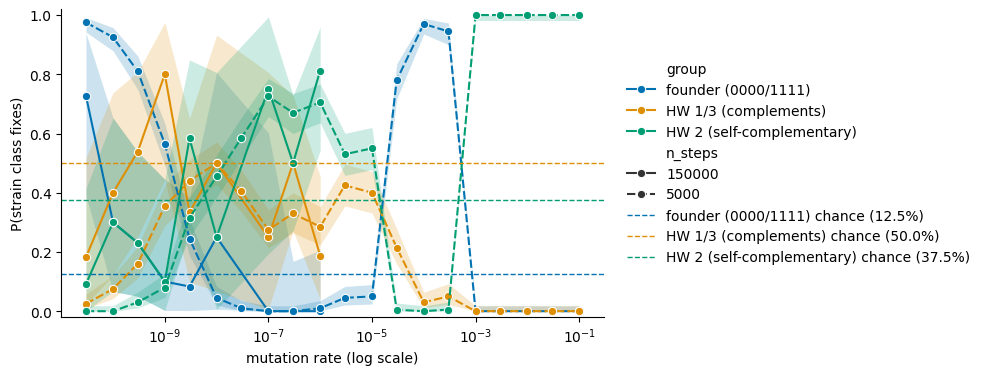

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)
# Genome-count fraction of the 16 possible 4-site genomes each group
# covers, under a uniform-over-genomes null: founder {0000, 1111}
# (2), HW 1/3 complements (2 * C(4,1) = 8), HW 2 self-complementary
# (C(4,2) = 6).
_chance = {
    "founder (0000/1111)": 2 / 16,
    "HW 1/3 (complements)": 8 / 16,
    "HW 2 (self-complementary)": 6 / 16,
}

_steps_order = sorted(summary_df["n_steps"].unique(), reverse=True)

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    style="n_steps",
    style_order=_steps_order,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={"a": "founder-vs-hw13-vs-hw2-fixation-prob"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per (group, n_steps) series (fill_between, not
    # bootstrap) --- kept separate since the two depths shouldn't
    # be pooled (see Data section).
    for _group in _groups:
        for _steps in _steps_order:
            _sub = summary_df[
                (summary_df["group"] == _group)
                & (summary_df["n_steps"] == _steps)
            ].sort_values("mutation_rate")
            if _sub.empty:
                continue
            _ax.fill_between(
                _sub["mutation_rate"],
                _sub["ci_low"],
                _sub["ci_high"],
                color=_palette[_group],
                alpha=0.2,
                linewidth=0,
            )
    # Color-matched chance-expectation rule per group.
    for _group in _groups:
        _ax.axhline(
            _chance[_group],
            color=_palette[_group],
            linestyle="--",
            linewidth=1.0,
            label=f"{_group} chance ({_chance[_group]:.1%})",
        )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`(mutation_rate, n_steps)` fixation probability with the exact
Clopper-Pearson 95% confidence interval, for all three outcome
groups. `n_fixed` / `n_total` are the binomial counts behind each
estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "n_steps",
            "mutation_rate",
            "n_fixed",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "n_steps", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

                    group  n_steps  mutation_rate  n_fixed  n_total      p  ci_low  ci_high          ci_95
     HW 1/3 (complements)     5000   3.000000e-11        5      200 0.0250  0.0082   0.0574 [0.008, 0.057]
     HW 1/3 (complements)     5000   1.000000e-10       15      200 0.0750  0.0426   0.1207 [0.043, 0.121]
     HW 1/3 (complements)     5000   3.000000e-10       32      200 0.1600  0.1121   0.2183 [0.112, 0.218]
     HW 1/3 (complements)     5000   1.000000e-09       71      200 0.3550  0.2888   0.4256 [0.289, 0.426]
     HW 1/3 (complements)     5000   3.000000e-09       88      200 0.4400  0.3701   0.5117 [0.370, 0.512]
     HW 1/3 (complements)     5000   1.000000e-08      100      200 0.5000  0.4287   0.5713 [0.429, 0.571]
     HW 1/3 (complements)     5000   3.000000e-08       81      200 0.4050  0.3363   0.4765 [0.336, 0.477]
     HW 1/3 (complements)     5000   1.000000e-07       55      200 0.2750  0.2144   0.3424 [0.214, 0.342]
     HW 1/3 (complements)     5000   

,group,n_steps,mutation_rate,n_fixed,n_total,p,ci_low,ci_high,ci_95
0,HW 1/3 (complements),5000,3.000000e-11,5,200,0.0250,0.0082,0.0574,"[0.008, 0.057]"
1,HW 1/3 (complements),5000,1.000000e-10,15,200,0.0750,0.0426,0.1207,"[0.043, 0.121]"
2,HW 1/3 (complements),5000,3.000000e-10,32,200,0.1600,0.1121,0.2183,"[0.112, 0.218]"
3,HW 1/3 (complements),5000,1.000000e-09,71,200,0.3550,0.2888,0.4256,"[0.289, 0.426]"
4,HW 1/3 (complements),5000,3.000000e-09,88,200,0.4400,0.3701,0.5117,"[0.370, 0.512]"
...,...,...,...,...,...,...,...,...,...
82,founder (0000/1111),150000,3.000000e-09,1,12,0.0833,0.0021,0.3848,"[0.002, 0.385]"
83,founder (0000/1111),150000,1.000000e-08,1,4,0.2500,0.0063,0.8059,"[0.006, 0.806]"
84,founder (0000/1111),150000,1.000000e-07,0,4,0.0000,0.0000,0.6024,"[0.000, 0.602]"
85,founder (0000/1111),150000,3.000000e-07,0,20,0.0000,0.0000,0.1684,"[0.000, 0.168]"
